# Module 06 — EDA Interactive Notebook
## GlobalTrust Banking Customer Analytics

---

### How to use this notebook
Run cells from top to bottom using **Shift+Enter**.
Each cell has a comment explaining what it does and why.

This notebook is the **interactive layer** on top of `run.py`.
While `run.py` produces text reports, this notebook produces:
- Visual charts (histograms, box plots, scatter plots, heatmaps)
- Interactive exploration of specific findings
- Deeper investigation of anomalies

**Business questions we answer here:**
1. Which banking product account types and branchs generate the highest transaction value per transaction?
2. Which branchs are underperforming relative to the account_type average?
3. Does loan_interest_discount percentage correlate with total transactions amount?
4. Which specific banking transactions are statistical anomalies?

In [1]:
# ── Cell 1: Imports and Setup ─────────────────────────────────────────────
# Before anything else, we import the libraries we need.
# These are the standard imports for any EDA notebook.

import sys
import pathlib

# Add the project root to Python path so we can import our classes
# pathlib.Path.cwd() returns the current working directory
# We walk up until we find config.py
_root = pathlib.Path.cwd()
while not (_root / "config.py").exists() and _root != _root.parent:
    _root = _root.parent

if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt   # matplotlib: the core Python plotting library

# Tell matplotlib to display plots directly in the notebook (not in a separate window)
%matplotlib inline

# Set figure defaults for readable notebook charts
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

from config import DATA_PATH, REPORTS_DIR, TOP_N_GROUPS

# Create folder for notebook chart outputs
FIGURES_DIR = REPORTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
from src.eda_engine import EDAEngine
from src.anomaly_detector import AnomalyDetector

print(f"Project root: {_root}")
print(f"Data path:    {DATA_PATH}")
print(f"Reports dir:  {REPORTS_DIR}")
print(f"Figures dir:  {FIGURES_DIR}")

2026-05-24 13:14:30 [INFO] Database connection successful.


Project root: c:\student-projects eda\P02-banking-eda
Data path:    C:\student-projects eda\P02-banking-eda\data\processed\processed-data.csv
Reports dir:  C:\student-projects eda\P02-banking-eda\reports
Figures dir:  C:\student-projects eda\P02-banking-eda\reports\figures


In [2]:
# ── Cell 2: Load and Profile the Data ────────────────────────────────────
# We use our EDAEngine class to load and profile the data.
# This is the same code that run.py executes — but here we can
# inspect intermediate results interactively.

engine = EDAEngine()
engine.load().profile()

# Access the profile results dictionary directly
p = engine.results["profile"]

print("=" * 50)
print("  BANKING DATASET OVERVIEW")
print("=" * 50)
print(f"  Rows:          {p['rows']:,}")
print(f"  Columns:       {p['columns']}")
print(f"  Numeric cols:  {p['numeric_cols']}")
print(f"  Text cols:     {p['categorical_cols']}")
print(f"  Missing vals:  {p['total_nulls']:,} ({p['null_pct']}%)")
print(f"  Memory:        {p['memory_mb']} MB")

print("\nAvailable columns:")
print(list(engine.df.columns))


2026-05-24 13:14:49 [INFO] EDAEngine initialised — industry: banking
2026-05-24 13:14:49 [INFO] [EDA] Loading: processed-data.csv
2026-05-24 13:14:49 [INFO] [EDA] Loaded 50 rows × 55 columns
2026-05-24 13:14:49 [INFO] [EDA] Column types: 16 numeric, 31 categorical
2026-05-24 13:14:49 [INFO] [EDA] Computing dataset profile...
2026-05-24 13:14:49 [INFO] [EDA] Profile complete — 50 rows | 0.0% nulls


  BANKING DATASET OVERVIEW
  Rows:          50
  Columns:       55
  Numeric cols:  16
  Text cols:     31
  Missing vals:  0 (0.0%)
  Memory:        0.1 MB

Available columns:
['transaction_id', 'transaction_date', 'transaction_time', 'amount', 'transaction_type', 'merchant_name', 'merchant_category', 'channel', 'transaction_status', 'is_fraud', 'balance_after', 'account_id', 'account_type', 'account_number', 'balance', 'currency', 'opened_date', 'account_status', 'branch', 'interest_rate', 'customer_id', 'first_name', 'last_name', 'email', 'phone', 'date_of_birth', 'city', 'credit_score', 'customer_since', 'segment', 'is_active', 'loan_id', 'loan_type', 'principal', 'loan_interest_rate', 'term_months', 'monthly_payment', 'disbursed_date', 'outstanding_balance', 'loan_status', 'risk_grade', 'alert_id', 'alert_date', 'alert_type', 'severity', 'fraud_alert_status', 'amount_at_risk', 'credit_risk_band', 'transaction_month', 'interest_rate_is_outlier', 'credit_score_is_outlier', 'is_any_o

In [3]:
# ── Cell 3: Descriptive Statistics ───────────────────────────────────────
# pandas .describe() gives us the 8 key statistics for every numeric column.
# We display it as a formatted table directly in the notebook.

# Select only columns that are not pipeline metadata (starting with _)
analysis_df = engine.df.drop(
    columns=[c for c in engine.df.columns if c.startswith("_")],
    errors="ignore"
)

# Helper function:
# This prevents graph cells from crashing when your banking dataset uses
# slightly different column names.
def pick_col(df, candidates):
    """Return the first matching column from candidates, otherwise None."""
    for col in candidates:
        if col in df.columns:
            return col
    return None

# Banking-friendly column mapping.
# The notebook will use whichever column exists in your actual dataframe.
amount_col = pick_col(analysis_df, [
    "transaction_amount", "total_amount", "amount", "balance",
    "loan_amount", "deposit_amount", "withdrawal_amount", "payment_amount"
])

account_col = pick_col(analysis_df, [
    "account_type", "account_category", "product_type", "banking_product",
    "product_name", "category"
])

branch_col = pick_col(analysis_df, [
    "branch_name", "branch", "store_name", "location", "city", "region"
])

segment_col = pick_col(analysis_df, [
    "client_segment", "customer_segment", "customer_type", "customer_category"
])

discount_col = pick_col(analysis_df, [
    "interest_discount", "loan_interest_discount", "discount_pct",
    "interest_rate", "fee_discount"
])

transaction_count_col = pick_col(analysis_df, [
    "transaction_count", "quantity", "num_transactions", "transaction_volume"
])

print("Analysis dataframe created successfully.")
print(f"Rows: {analysis_df.shape[0]:,}")
print(f"Columns: {analysis_df.shape[1]}")
print("\nDetected banking columns:")
print(f"Amount column:      {amount_col}")
print(f"Account column:     {account_col}")
print(f"Branch column:      {branch_col}")
print(f"Segment column:     {segment_col}")
print(f"Discount/rate col:  {discount_col}")
print(f"Count/volume col:   {transaction_count_col}")

display(analysis_df.head())

# .describe() → count, mean, std, min, 25%, 50%, 75%, max for each numeric col
# .T transposes the table: columns become rows (easier to read with many columns)
desc = analysis_df.describe().round(2).T
desc


Analysis dataframe created successfully.
Rows: 50
Columns: 52

Detected banking columns:
Amount column:      amount
Account column:     account_type
Branch column:      branch
Segment column:     None
Discount/rate col:  interest_rate
Count/volume col:   None


,transaction_id,transaction_date,transaction_time,amount,transaction_type,merchant_name,merchant_category,channel,transaction_status,is_fraud,...,alert_date,alert_type,severity,fraud_alert_status,amount_at_risk,credit_risk_band,transaction_month,interest_rate_is_outlier,credit_score_is_outlier,is_any_outlier
0,1,2024-12-03,22:07,115.02,Credit,Uber,ATM,Branch,Completed,False,...,2022-06-15,Unknown,Unknown,Unknown,1181.11,Fair,2024-12,False,False,False
1,2,2023-07-24,18:33,44.37,Transfer,Target,ATM,Mobile,Completed,False,...,2022-06-15,Unknown,Unknown,Unknown,1181.11,Good,2023-07,False,False,False
2,3,2024-05-04,19:02,144.25,Transfer,Walmart,Entertainment,Mobile,Completed,False,...,2022-06-15,Unknown,Unknown,Unknown,1181.11,Poor,2024-05,False,False,False
3,4,2023-12-15,12:16,536.22,Payment,Shell,Utilities,POS,Failed,False,...,2022-06-15,Unknown,Unknown,Unknown,1181.11,Poor,2023-12,False,False,False
4,5,2023-08-15,13:22,38.43,Transfer,Delta,ATM,Branch,Completed,False,...,2022-06-15,Unknown,Unknown,Unknown,1181.11,Poor,2023-08,False,False,False


,count,mean,std,min,25%,50%,75%,max
transaction_id,50.0,17.28,8.81,1.00,10.25,17.00,24.75,32.00
amount,50.0,99.89,203.58,3.10,11.95,27.08,63.46,878.68
balance_after,50.0,28818.04,13992.02,2702.08,16468.67,33831.65,40896.04,48056.63
account_id,50.0,5553.92,2918.68,99.00,3819.75,6195.00,8275.00,9732.00
balance,50.0,151805.88,69573.78,6391.17,104473.31,172849.76,204124.53,248797.63
interest_rate,50.0,0.02,0.01,0.00,0.01,0.02,0.04,0.04
customer_id,50.0,4131.10,2042.97,282.00,2540.75,3986.00,6162.00,7524.00
credit_score,50.0,511.02,132.72,343.00,400.75,484.00,626.00,774.00
loan_id,50.0,7453.50,3266.36,129.00,5322.50,7754.00,9963.75,11955.00
principal,50.0,297046.14,140484.04,28355.17,180059.12,311995.18,418024.87,491212.79


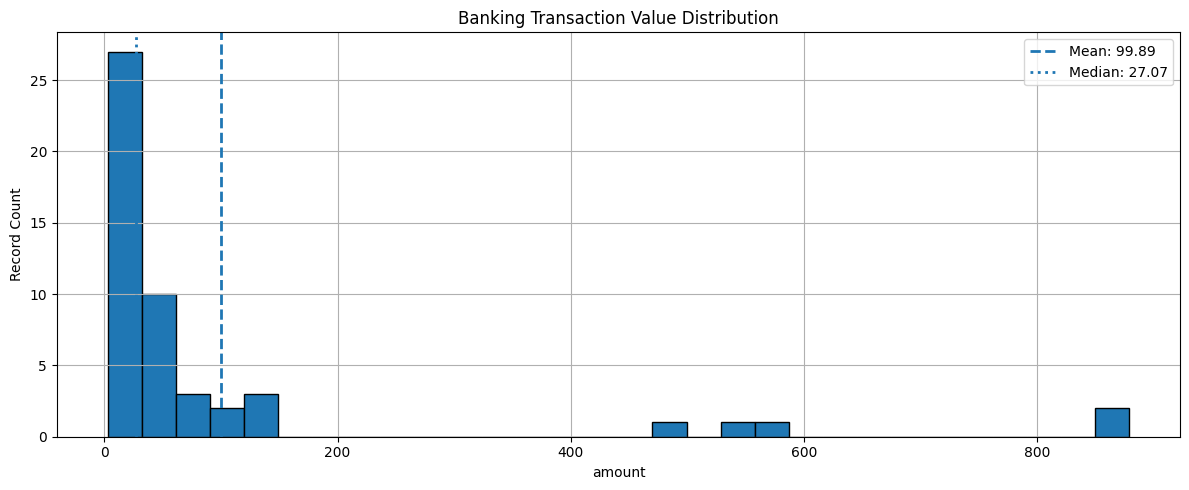

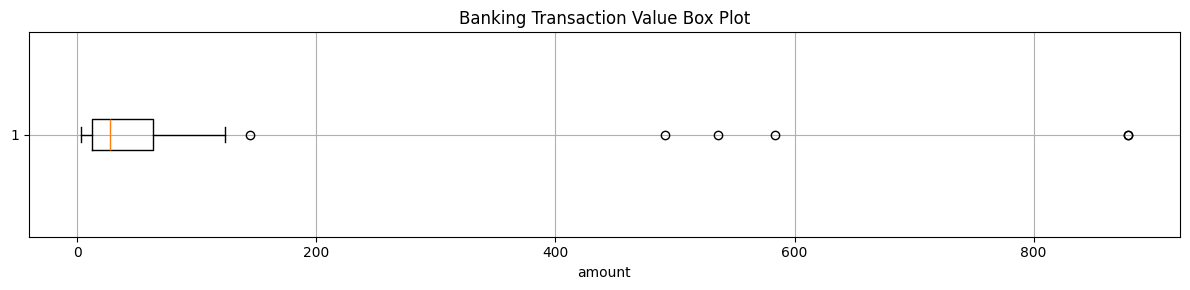

In [4]:
# ── Cell 4: Transaction Value Distribution — Histogram and Box Plot ───────
# A histogram shows how values are distributed across ranges.
# BINS divide the value range into equal segments and count how many
# values fall in each bin.
#
# What to look for:
#   Normal pattern      → transactions cluster around a typical banking value
#   Right skewed        → most transactions are low, a few are very high
#   Extreme values      → possible large payments, unusual balances, or data issues

if amount_col is not None:
    transaction_values = pd.to_numeric(analysis_df[amount_col], errors="coerce").dropna()

    if transaction_values.empty:
        print(f"Column '{amount_col}' exists, but it has no numeric values to plot.")
    else:
        fig, ax = plt.subplots(figsize=(12, 5))
        ax.hist(transaction_values, bins=30, edgecolor="black")
        ax.axvline(transaction_values.mean(), linestyle="--", linewidth=2, label=f"Mean: {transaction_values.mean():,.2f}")
        ax.axvline(transaction_values.median(), linestyle=":", linewidth=2, label=f"Median: {transaction_values.median():,.2f}")
        ax.set_title("Banking Transaction Value Distribution")
        ax.set_xlabel(amount_col)
        ax.set_ylabel("Record Count")
        ax.legend()
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / "banking_transaction_value_distribution.png", dpi=300, bbox_inches="tight")
        plt.show()

        fig, ax = plt.subplots(figsize=(12, 3))
        ax.boxplot(transaction_values, vert=False)
        ax.set_title("Banking Transaction Value Box Plot")
        ax.set_xlabel(amount_col)
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / "banking_transaction_value_boxplot.png", dpi=300, bbox_inches="tight")
        plt.show()
else:
    print("No banking amount column was found. Check your CSV column names above.")


,account_type,transaction_count,total_transaction_value,average_transaction_value,rank
3,Money Market,8,1930.12,241.26,1
1,CD,8,997.74,124.72,2
2,Checking,21,1680.61,80.03,3
0,Business,4,180.50,45.12,4
4,Savings,9,205.68,22.85,5


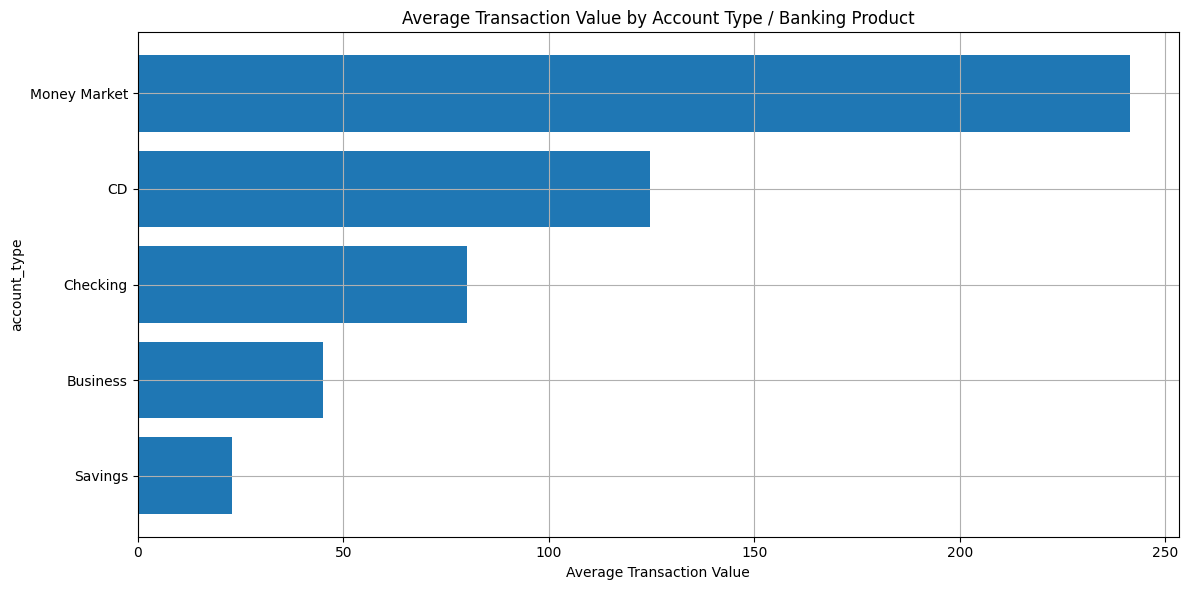

In [5]:
# ── Cell 5: Transaction Performance by Account Type ──────────────────────
# Bar charts are the most intuitive way to compare group-level metrics.
# Here we rank account types or banking products by average transaction value.

if account_col is not None and amount_col is not None:
    account_performance = (
        analysis_df
        .assign(_amount=pd.to_numeric(analysis_df[amount_col], errors="coerce"))
        .dropna(subset=["_amount"])
        .groupby(account_col, dropna=False)
        .agg(
            transaction_count=("_amount", "count"),
            total_transaction_value=("_amount", "sum"),
            average_transaction_value=("_amount", "mean")
        )
        .reset_index()
        .sort_values("average_transaction_value", ascending=False)
    )

    account_performance["rank"] = range(1, len(account_performance) + 1)

    display(account_performance.round(2))

    plot_df = account_performance.sort_values("average_transaction_value", ascending=True)

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.barh(plot_df[account_col].astype(str), plot_df["average_transaction_value"])
    ax.set_title("Average Transaction Value by Account Type / Banking Product")
    ax.set_xlabel("Average Transaction Value")
    ax.set_ylabel(account_col)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "banking_value_by_account_type.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("This chart needs both an account/product column and a transaction amount column.")
    print(f"Detected account_col={account_col}, amount_col={amount_col}")


,branch,transaction_count,total_transaction_value,average_transaction_value,rank
0,Downtown,6,1945.60,324.27,1
4,Westside,3,555.64,185.21,2
1,Midtown,14,1144.14,81.72,3
3,Uptown,15,969.51,64.63,4
2,Online,12,379.76,31.65,5


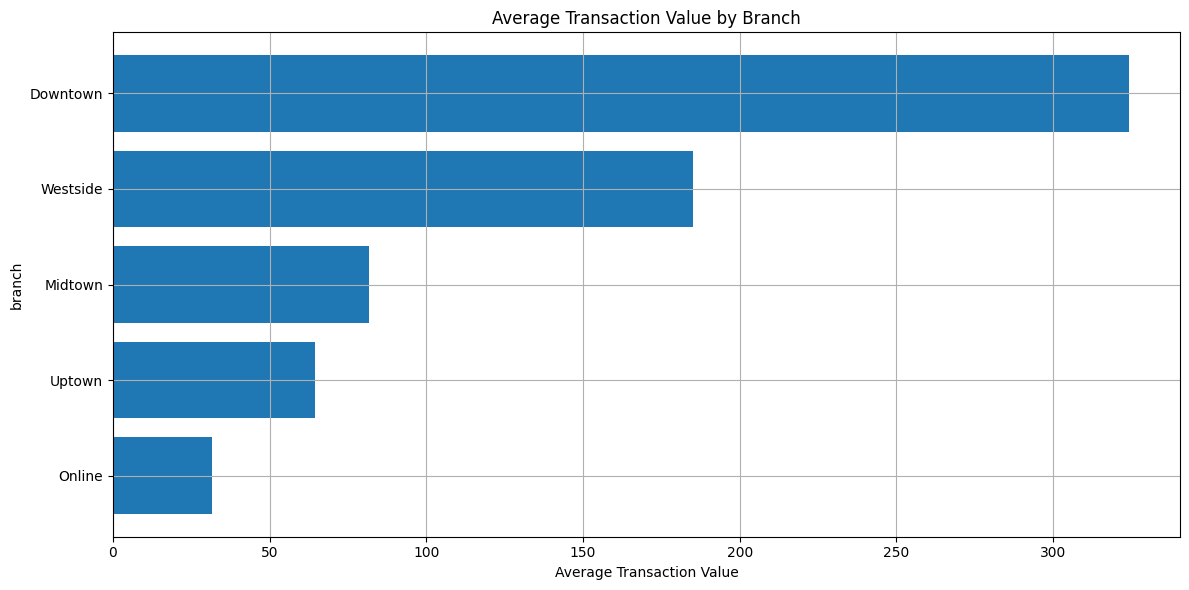

In [6]:
# ── Cell 6: Transaction Performance by Branch ────────────────────────────
# This shows which branches generate the highest average transaction value.
# It also helps identify underperforming branches before management review.

if branch_col is not None and amount_col is not None:
    branch_performance = (
        analysis_df
        .assign(_amount=pd.to_numeric(analysis_df[amount_col], errors="coerce"))
        .dropna(subset=["_amount"])
        .groupby(branch_col, dropna=False)
        .agg(
            transaction_count=("_amount", "count"),
            total_transaction_value=("_amount", "sum"),
            average_transaction_value=("_amount", "mean")
        )
        .reset_index()
        .sort_values("average_transaction_value", ascending=False)
    )

    branch_performance["rank"] = range(1, len(branch_performance) + 1)

    display(branch_performance.round(2))

    plot_df = branch_performance.sort_values("average_transaction_value", ascending=True)

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.barh(plot_df[branch_col].astype(str), plot_df["average_transaction_value"])
    ax.set_title("Average Transaction Value by Branch")
    ax.set_xlabel("Average Transaction Value")
    ax.set_ylabel(branch_col)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "banking_value_by_branch.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("This chart needs both a branch/location column and a transaction amount column.")
    print(f"Detected branch_col={branch_col}, amount_col={amount_col}")


,account_type,branch,transaction_count,branch_account_avg,account_type_avg,difference_from_account_type_avg,performance_flag
12,Money Market,Online,4,16.78,241.26,-224.48,Underperforming
6,CD,Westside,2,9.71,124.72,-115.01,Underperforming
8,Checking,Online,1,3.10,80.03,-76.93,Underperforming
2,CD,Downtown,1,60.42,124.72,-64.30,Underperforming
9,Checking,Uptown,12,32.15,80.03,-47.88,Underperforming
0,Business,Downtown,1,22.18,45.12,-22.94,Underperforming
14,Savings,Online,5,12.63,22.85,-10.23,Underperforming
3,CD,Midtown,1,115.02,124.72,-9.70,Underperforming
4,CD,Online,2,123.20,124.72,-1.52,Underperforming
15,Savings,Uptown,1,27.25,22.85,4.40,At or Above Average


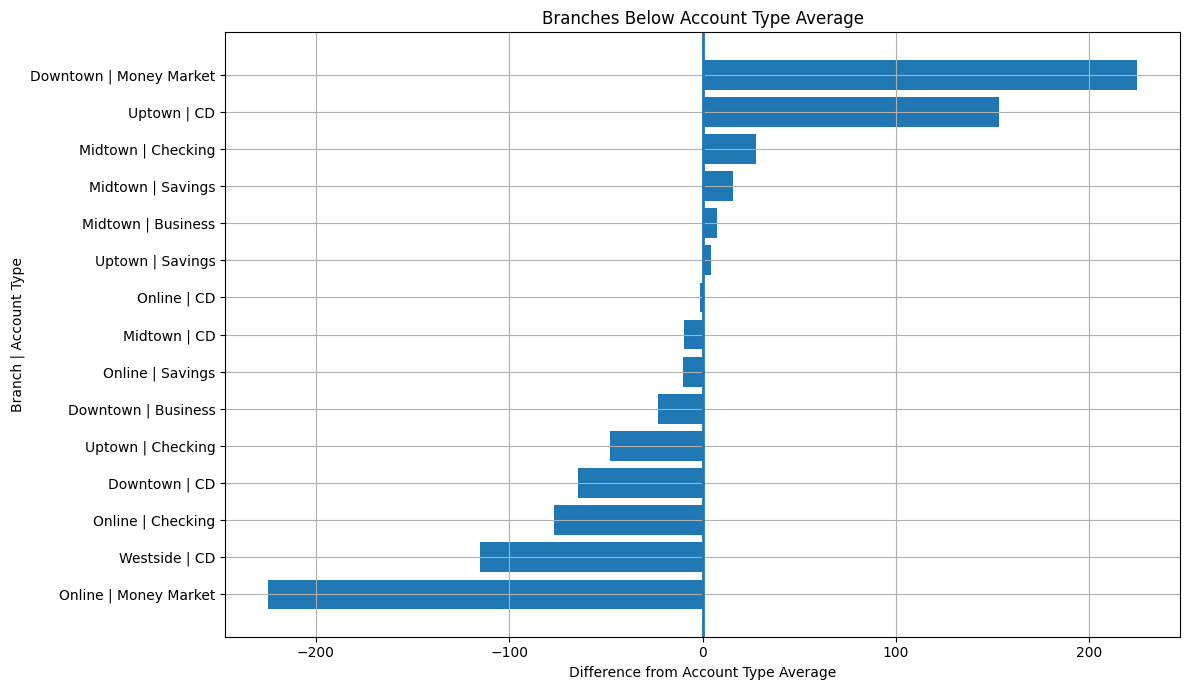

In [7]:
# ── Cell 7: Branch Performance Relative to Account Type Average ──────────
# The business question asks:
# Which branches are underperforming relative to the account type average?
#
# We compare each branch/account average transaction value against the
# overall account type average transaction value.

if branch_col is not None and account_col is not None and amount_col is not None:
    temp_df = analysis_df.assign(_amount=pd.to_numeric(analysis_df[amount_col], errors="coerce")).dropna(subset=["_amount"])

    branch_account = (
        temp_df
        .groupby([account_col, branch_col], dropna=False)
        .agg(
            transaction_count=("_amount", "count"),
            branch_account_avg=("_amount", "mean")
        )
        .reset_index()
    )

    account_avg = (
        temp_df
        .groupby(account_col, dropna=False)
        .agg(account_type_avg=("_amount", "mean"))
        .reset_index()
    )

    performance = branch_account.merge(account_avg, on=account_col, how="left")
    performance["difference_from_account_type_avg"] = (
        performance["branch_account_avg"] - performance["account_type_avg"]
    ).round(2)

    performance["performance_flag"] = np.where(
        performance["difference_from_account_type_avg"] < 0,
        "Underperforming",
        "At or Above Average"
    )

    performance = performance.sort_values("difference_from_account_type_avg")

    display(performance.round(2).head(20))

    plot_df = performance.head(15).sort_values("difference_from_account_type_avg", ascending=True)

    fig, ax = plt.subplots(figsize=(12, 7))
    labels = plot_df[branch_col].astype(str) + " | " + plot_df[account_col].astype(str)
    ax.barh(labels, plot_df["difference_from_account_type_avg"])
    ax.axvline(0, linewidth=2)
    ax.set_title("Branches Below Account Type Average")
    ax.set_xlabel("Difference from Account Type Average")
    ax.set_ylabel("Branch | Account Type")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "branch_vs_account_type_average.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("This chart needs branch, account/product, and amount columns.")
    print(f"Detected branch_col={branch_col}, account_col={account_col}, amount_col={amount_col}")


  BANKING RATE / DISCOUNT IMPACT
Pearson correlation between interest_rate and amount: -0.1059
Interpretation: The relationship is weak or close to zero.


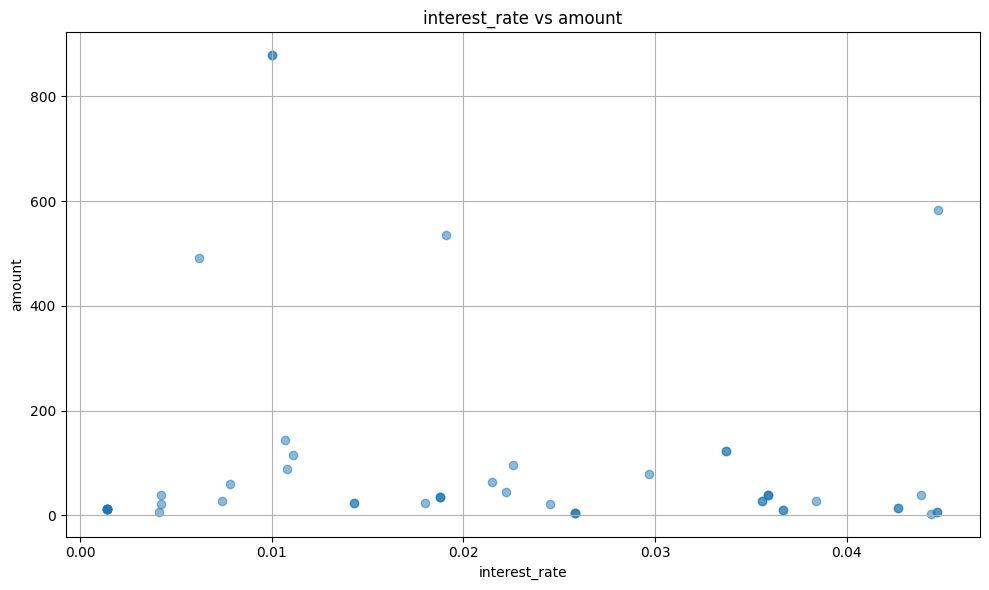

In [8]:
# ── Cell 8: Rate / Discount Impact — Pearson Correlation ─────────────────
# The business question asks:
# Does offering a lower rate, discount, or promotion correlate with higher transaction value?
#
# Here we compute the Pearson correlation between the detected discount/rate column
# and the detected transaction amount column.
# Positive correlation: higher values in the rate/discount column are associated with higher transaction values.
# Negative correlation: higher values in the rate/discount column are associated with lower transaction values.
# Near zero: weak linear relationship.

if discount_col is not None and amount_col is not None:
    discount_or_rate = pd.to_numeric(analysis_df[discount_col], errors="coerce")
    transaction_values = pd.to_numeric(analysis_df[amount_col], errors="coerce")

    corr = discount_or_rate.corr(transaction_values)

    print("=" * 60)
    print("  BANKING RATE / DISCOUNT IMPACT")
    print("=" * 60)
    print(f"Pearson correlation between {discount_col} and {amount_col}: {corr:.4f}")

    if corr < -0.3:
        print("Interpretation: Higher values in the rate/discount column are associated with lower transaction values.")
    elif corr > 0.3:
        print("Interpretation: Higher values in the rate/discount column are associated with higher transaction values.")
    else:
        print("Interpretation: The relationship is weak or close to zero.")

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(discount_or_rate, transaction_values, alpha=0.5)
    ax.set_title(f"{discount_col} vs {amount_col}")
    ax.set_xlabel(discount_col)
    ax.set_ylabel(amount_col)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "banking_rate_discount_vs_amount.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("This analysis needs both a rate/discount column and an amount column.")
    print(f"Detected discount_col={discount_col}, amount_col={amount_col}")


2026-05-24 13:16:58 [INFO] [EDA] Computing correlation matrix...
2026-05-24 13:16:58 [INFO] [EDA] Correlation: 39 meaningful pairs (threshold |r| > 0.3)


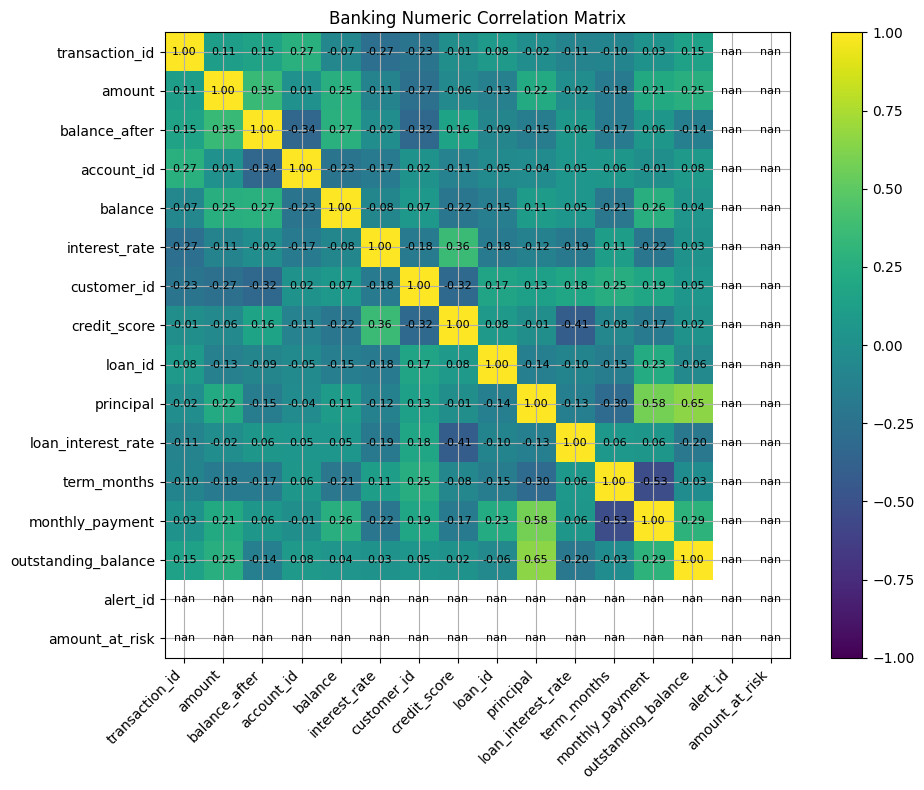

In [9]:
# ── Cell 9: Correlation Heatmap ───────────────────────────────────────────
# A heatmap visualises the entire correlation matrix at once.
# Each cell is coloured by the correlation value:
#   Positive value → variables move together
#   Negative value → one variable rises while the other falls
#   Near zero      → weak linear relationship
#
# This is how analysts quickly identify:
#   - Which banking metrics are strongly related to transaction value
#   - Which features are redundant or related to each other

engine.correlation()

numeric_df = analysis_df.select_dtypes(include=["number"])

if numeric_df.shape[1] >= 2:
    corr_df = numeric_df.corr()

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(corr_df, vmin=-1, vmax=1)

    ax.set_xticks(range(len(corr_df.columns)))
    ax.set_yticks(range(len(corr_df.columns)))
    ax.set_xticklabels(corr_df.columns, rotation=45, ha="right")
    ax.set_yticklabels(corr_df.columns)

    for i in range(len(corr_df.columns)):
        for j in range(len(corr_df.columns)):
            ax.text(j, i, f"{corr_df.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

    ax.set_title("Banking Numeric Correlation Matrix")
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "banking_correlation_heatmap.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Not enough numeric columns to create a correlation heatmap.")


In [11]:
# ── Cell 10: Anomaly Detection ────────────────────────────────────────────
# Now we run the AnomalyDetector on the loaded data.
# Confirmed anomalies are those flagged by BOTH IQR and Z-score.
#
# For banking, the most important anomaly columns are usually:
#   transaction_amount, balance, loan_amount, interest_rate,
#   fee_amount, transaction_count, reversal_amount

banking_anomaly_candidates = [
    "transaction_amount",
    "total_amount",
    "amount",
    "balance",
    "loan_amount",
    "deposit_amount",
    "withdrawal_amount",
    "payment_amount",
    "interest_rate",
    "interest_discount",
    "loan_interest_discount",
    "fee_amount",
    "transaction_count",
    "quantity",
    "reversal_amount",
    "refund_amount"
]

anomaly_columns = [col for col in banking_anomaly_candidates if col in engine.df.columns]

detector = AnomalyDetector(engine.df)

if anomaly_columns:
    detector.run(columns=anomaly_columns)

    print("Anomaly Detection Summary:")
    print(detector.summary().to_string(index=False))
    print(f"\nTotal confirmed anomaly rows: {len(detector.confirmed):,}")

    if len(detector.confirmed) > 0:
        display(detector.confirmed.head(20))
else:
    print("No suitable numeric banking anomaly columns were found.")
    print("Available columns:")
    print(list(engine.df.columns))


2026-05-24 13:17:30 [INFO] AnomalyDetector initialised — 50 rows to scan
2026-05-24 13:17:30 [INFO] [ANOMALY] amount: IQR=6 | Z-score=2 | Confirmed=2
2026-05-24 13:17:30 [INFO] [ANOMALY] balance: IQR=0 | Z-score=0 | Confirmed=0
2026-05-24 13:17:30 [INFO] [ANOMALY] interest_rate: IQR=0 | Z-score=0 | Confirmed=0
2026-05-24 13:17:30 [INFO] [ANOMALY] Scan complete: 2 confirmed anomaly rows found


Anomaly Detection Summary:
       column  iqr_flagged  zscore_flagged  confirmed_anomalies  anomaly_pct
       amount            6               2                    2          4.0
      balance            0               0                    0          0.0
interest_rate            0               0                    0          0.0

Total confirmed anomaly rows: 2


,transaction_id,transaction_date,transaction_time,amount,transaction_type,merchant_name,merchant_category,channel,transaction_status,is_fraud,...,fraud_alert_status,amount_at_risk,credit_risk_band,transaction_month,interest_rate_is_outlier,credit_score_is_outlier,is_any_outlier,_industry,_processed_at,_pipeline_version
48,32,2024-05-21,20:30,878.68,Payment,Delta,Healthcare,ATM,Pending,False,...,Unknown,1181.11,Poor,2024-05,False,False,False,banking,2026-05-24T12:30:20.230554,1.0.0
49,32,2024-05-21,20:30,878.68,Payment,Delta,Healthcare,ATM,Pending,False,...,Unknown,1181.11,Poor,2024-05,False,False,False,banking,2026-05-24T12:30:20.230554,1.0.0


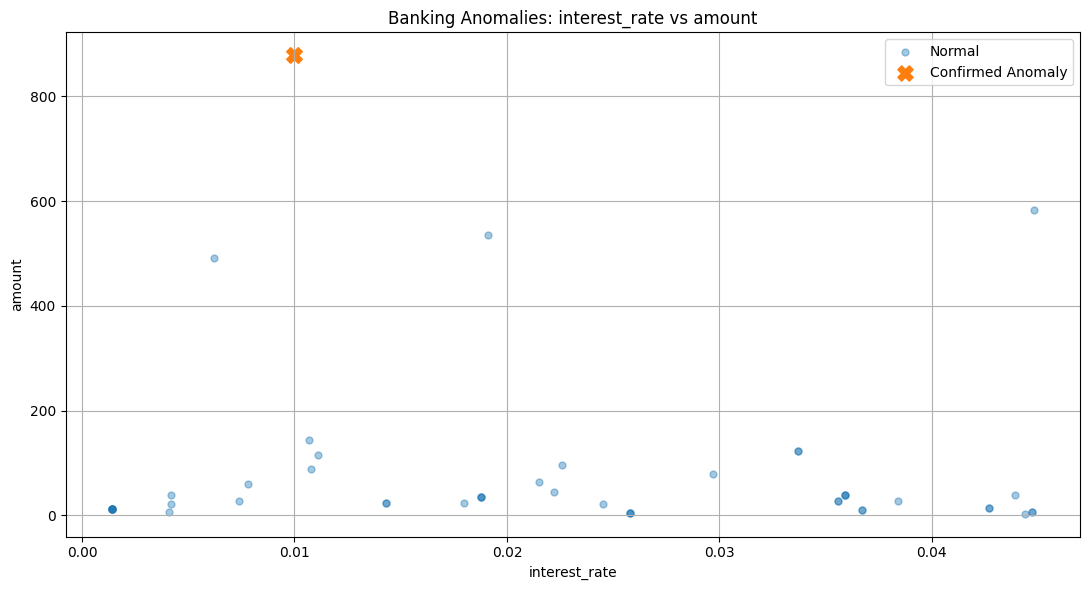

In [12]:
# ── Cell 11: Visualise Anomalies ──────────────────────────────────────────
# Show which rows are anomalies on the scatter plot.
# Normal rows = small circles
# Anomaly rows = large X marks
#
# For banking, the amount column is the main Y-axis because unusual transaction,
# balance, loan, or payment values are important for risk and compliance review.

x_col = discount_col if discount_col is not None else transaction_count_col
y_col = amount_col

if "detector" in globals() and hasattr(detector, "confirmed") and len(detector.confirmed) > 0 and x_col and y_col:
    analysis_df = engine.df.drop(
        columns=[c for c in engine.df.columns if c.startswith("_")],
        errors="ignore"
    )

    normal_mask = ~engine.df.index.isin(detector.confirmed.index)
    normal_rows = analysis_df[normal_mask]
    anomaly_rows = analysis_df[~normal_mask]

    fig, ax = plt.subplots(figsize=(11, 6))

    ax.scatter(
        pd.to_numeric(normal_rows[x_col], errors="coerce"),
        pd.to_numeric(normal_rows[y_col], errors="coerce"),
        alpha=0.4,
        s=25,
        label="Normal"
    )

    ax.scatter(
        pd.to_numeric(anomaly_rows[x_col], errors="coerce"),
        pd.to_numeric(anomaly_rows[y_col], errors="coerce"),
        marker="X",
        s=120,
        label="Confirmed Anomaly"
    )

    ax.set_title(f"Banking Anomalies: {x_col} vs {y_col}")
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "banking_anomaly_scatter.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("No anomaly scatter plot created.")
    print("Possible reasons: no confirmed anomalies, no amount column, or no suitable x-axis column.")
    print(f"Detected x_col={x_col}, y_col={y_col}")


In [13]:
# ── Cell 12: Save Anomalies for Review ───────────────────────────────────
# The anomalies file can be opened in Excel by the banking operations,
# compliance, or risk-review team.
# This supports human investigation of unusual banking records.

REPORTS_DIR.mkdir(parents=True, exist_ok=True)

if "detector" in globals() and hasattr(detector, "save_anomalies"):
    detector.save_anomalies()
    print(f"Anomalies saved to: {REPORTS_DIR / 'anomalies.csv'}")
else:
    print("Detector was not created, so no anomalies file was saved.")


2026-05-24 13:17:49 [INFO] [ANOMALY] 2 anomaly rows saved: C:\student-projects eda\P02-banking-eda\reports\anomalies.csv


Anomalies saved to: C:\student-projects eda\P02-banking-eda\reports\anomalies.csv


## Summary and Next Steps

This banking EDA notebook helps identify transaction patterns, branch performance, account-type performance, correlations, and possible anomalies.

Use the printed detected column names in Cell 3 to confirm that the notebook is reading your banking dataset correctly. If a chart is skipped, it means the required column was not found in the CSV, not that the notebook has crashed.
